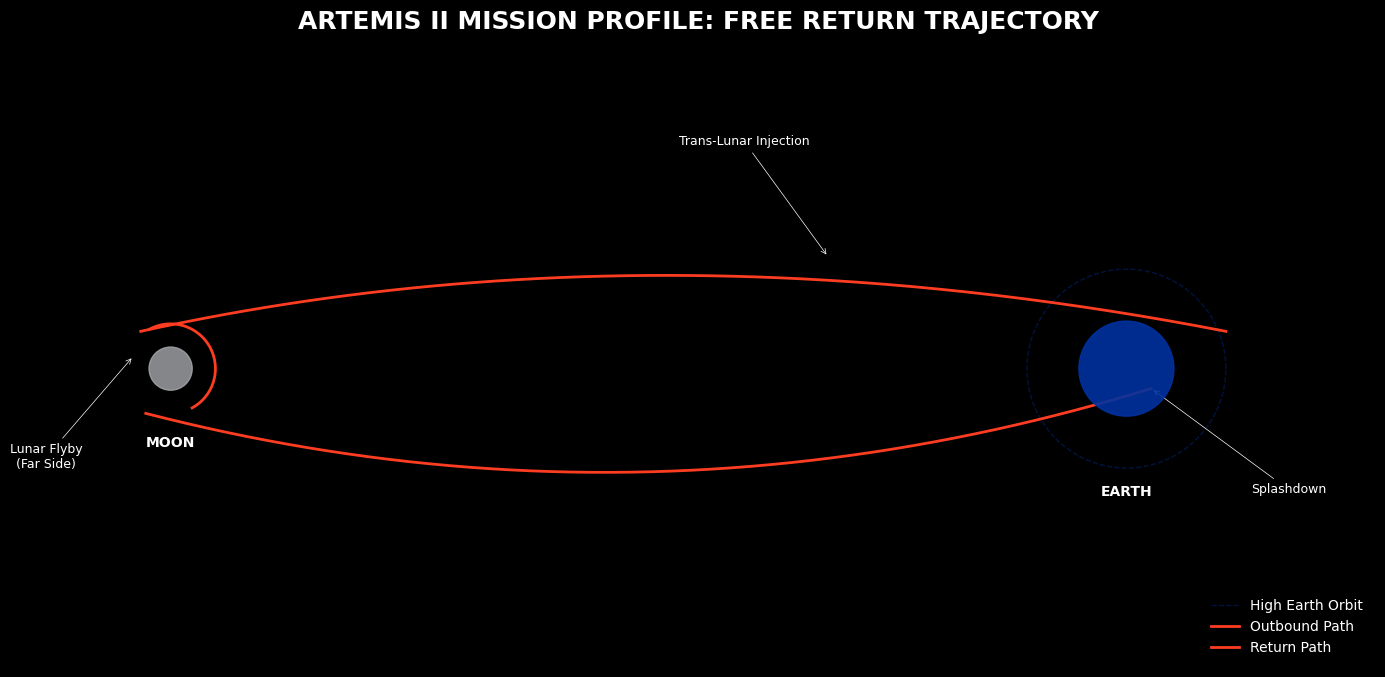

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

def plot_artemis_2_trajectory():
    # Set the style to dark for a space theme
    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # --- Constants and Configuration ---
    NASA_BLUE = '#0032A0'
    NASA_RED = '#FC3D21'
    MOON_GRAY = '#A7A9AC'
    EARTH_RADIUS = 6371
    MOON_DISTANCE = 384400  # km
    MOON_RADIUS = 1737
    
    # --- 1. Draw Earth and Moon ---
    # Scaled Earth (slightly enlarged for visibility)
    earth = Circle((0, 0), EARTH_RADIUS * 3, color=NASA_BLUE, alpha=0.9, zorder=5)
    ax.add_patch(earth)
    ax.text(0, -EARTH_RADIUS * 8, 'EARTH', color='white', ha='center', fontweight='bold', fontsize=10)
    
    # Scaled Moon
    moon_pos = (-MOON_DISTANCE, 0)
    moon = Circle(moon_pos, MOON_RADIUS * 5, color=MOON_GRAY, alpha=0.8, zorder=5)
    ax.add_patch(moon)
    ax.text(moon_pos[0], -MOON_RADIUS * 18, 'MOON', color='white', ha='center', fontweight='bold', fontsize=10)

    # --- 2. Generate Trajectory Paths ---
    # Earth Orbit Phase (Simplified Ellipse)
    t_orbit = np.linspace(0, 2 * np.pi, 100)
    ax.plot(40000 * np.cos(t_orbit), 40000 * np.sin(t_orbit), 
            color=NASA_BLUE, linestyle='--', alpha=0.4, linewidth=1, label='High Earth Orbit')

    # Outbound Trajectory (Bezier Curve approximation)
    t = np.linspace(0, 1, 200)
    # Start near Earth, curve toward Moon's top
    out_x = (1-t)**2 * 40000 + 2*(1-t)*t * (-MOON_DISTANCE/2) + t**2 * (-MOON_DISTANCE - 12000)
    out_y = (1-t)**2 * 15000 + 2*(1-t)*t * 60000 + t**2 * 15000
    ax.plot(out_x, out_y, color=NASA_RED, linewidth=2, label='Outbound Path')

    # Lunar Flyby (The "Loop" behind the moon)
    fly_t = np.linspace(-np.pi/2, np.pi/2, 100)
    fly_x = -MOON_DISTANCE + 18000 * np.cos(fly_t + 0.5)
    fly_y = 18000 * np.sin(fly_t + 0.5)
    ax.plot(fly_x, fly_y, color=NASA_RED, linewidth=2)

    # Return Trajectory
    ret_x = (1-t)**2 * (-MOON_DISTANCE - 10000) + 2*(1-t)*t * (-MOON_DISTANCE/2) + t**2 * 10000
    ret_y = (1-t)**2 * (-18000) + 2*(1-t)*t * (-70000) + t**2 * (-8000)
    ax.plot(ret_x, ret_y, color=NASA_RED, linewidth=2, linestyle='-', label='Return Path')

    # --- 3. Aesthetic Formatting ---
    ax.set_aspect('equal')
    ax.set_xlim(-MOON_DISTANCE - 60000, 100000)
    ax.set_ylim(-120000, 120000)
    ax.axis('off')  # Hide axes for a clean infographic look
    
    # Title and Labels
    plt.title('ARTEMIS II MISSION PROFILE: FREE RETURN TRAJECTORY', 
              color='white', fontsize=18, fontweight='bold', pad=30, family='sans-serif')
    
    # Annotations
    ax.annotate('Trans-Lunar Injection', xy=(-120000, 45000), xytext=(-180000, 90000),
                arrowprops=dict(arrowstyle='->', color='white', lw=0.5), color='white', fontsize=9)
    
    ax.annotate('Lunar Flyby\n(Far Side)', xy=(-MOON_DISTANCE-15000, 5000), xytext=(-MOON_DISTANCE-50000, -40000),
                arrowprops=dict(arrowstyle='->', color='white', lw=0.5), color='white', fontsize=9, ha='center')
    
    ax.annotate('Splashdown', xy=(10000, -8000), xytext=(50000, -50000),
                arrowprops=dict(arrowstyle='->', color='white', lw=0.5), color='white', fontsize=9)

    # Legend
    leg = ax.legend(loc='lower right', frameon=False, fontsize=10)
    for text in leg.get_texts():
        text.set_color('white')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_artemis_2_trajectory()